# Example on Quantum Born machine
This notebook is inspired from the tutorial [Born Machines with Pennylene](https://pennylane.ai/demos/tutorial_qcbm) from the Qiskit Machine Learning module. We will train a quantum circuit to learn a simple distribution over 3x3 binary images, called "Bars-and-Stripes". The goal is to show how to use a quantum circuit as a generative model, and how to train it using classical optimization. 


In [21]:
%%capture
# install packages
!pip install torch
!pip install scikit-learn
!pip install pennylane
!pip install matplotlib

In [22]:
%%capture
# import packages
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp   
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
import warnings
warnings.filterwarnings('ignore')       

### Create a simple dataset: Bars-and-Stripes 

In [23]:
grid = 2                                      # our 2x2 image
num_qubits = grid * grid                      # with one qubit per pixel
dim = 2 ** num_qubits                         # 16 possible images as there are 4 bits
 
def bas_patterns(n=grid):
    """All n x n images made of full rows ('stripes') or full
    columns ('bars'). Returns an array of shape (14, n, n) for gridsize=2."""
    pats = set()
    for bits in range(2 ** n):
        b = np.array([(bits >> i) & 1 for i in range(n)])
        pats.add(tuple(np.repeat(b, n)))            # stripes: row i = b[i]
        pats.add(tuple(np.tile(b, n)))              # bars:    col j = b[j]
    return np.array(sorted(pats)).reshape(-1, n, n)
 
patterns = bas_patterns()
print(f"Number of valid Bars-and-Stripes patterns: {len(patterns)} out of {dim}")

Number of valid Bars-and-Stripes patterns: 6 out of 16


### Transform the dataset into a probability distribution

In [24]:
# convert between images and integers 
def image_to_int(img):
    return int("".join(map(str, img.flatten())), 2)
 
# convert between integer and images 
def int_to_image(k):
    return np.array(list(np.binary_repr(k, width=num_qubits)),
                    dtype=int).reshape(grid, grid)
 
valid_ints = {image_to_int(p) for p in patterns}

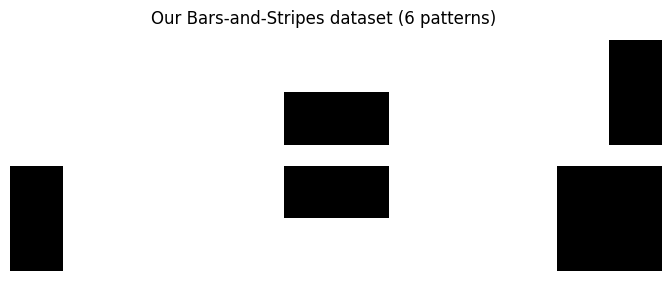

In [25]:
# Target distribution: uniform over the 14 valid patterns
p_data = np.zeros(dim)
p_data[list(valid_ints)] = 1.0 / len(valid_ints)
 
# Visualize the entire "dataset" — all 6 patterns
fig, axes = plt.subplots(2, 3, figsize=(10, 3))
for ax, img in zip(axes.flat, patterns):
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1); ax.axis("off")
fig.suptitle("Our Bars-and-Stripes dataset (6 patterns)")
plt.show()

### Define the Ansatz quantum circuit and initialize parameters at random
**Question**: Can you implement the ansatz circuits using gates 'qml.RY' and 'qml.RZ' as parametrized single-qubit roations, and 'qml.CX' as the entangling gate as visualized in the image below? What is the dimension of the weight array 'weights'? Hint: the ansatz has 'num_layers' layers, each with 'num_qubits' qubits, and each rotation gate has 2 parameters (RY and RZ). Can you try out other gates and/or entangling patterns? What do you observe?

![caption](figures/circuit_layer.png)

In [ ]:
num_layers = 5
 
dev = qml.device("default.qubit", wires=num_qubits)
 
@qml.qnode(dev)
def qcbm_probs(weights):
    """Create anasatz circuit to create a 512-dim output distribution p_theta."""
    for layer in range(num_layers):
        ###############################################################################################
        ########################## implement a layer as ansatz circuit here ###########################

        ###############################################################################################
    return qml.probs(wires=range(num_qubits))
 
# initialize the weights randomly in [0, 2pi], and set requires_grad=True to optimize them 
weights = pnp.random.uniform(0, 2 * np.pi, size=(num_layers, num_qubits, 2), requires_grad=True)
 
# here you can draw the circuit for the first layer to see what it looks like
print(qml.draw(qcbm_probs, max_length=50)(weights))
print(f"Number of trainable parameters: {weights.size}")

0: ──RY(1.94)──RZ(5.66)─╭●──RY(4.55)──RZ(3.68) ···
1: ──RY(3.37)──RZ(5.17)─╰X─╭●─────────RY(5.66) ···
2: ──RY(1.40)──RZ(2.26)────╰X────────╭●─────── ···
3: ──RY(5.35)──RZ(3.39)──────────────╰X─────── ···

0: ··· ───────────╭●─────────RY(2.10) ···
1: ··· ──RZ(3.10)─╰X────────╭●─────── ···
2: ··· ──RY(5.85)──RZ(2.02)─╰X─────── ···
3: ··· ──RY(1.48)──RZ(0.46)────────── ···

0: ··· ──RZ(4.92)───────────╭●─────── ···
1: ··· ──RY(6.05)──RZ(4.54)─╰X─────── ···
2: ··· ─╭●─────────RY(4.08)──RZ(0.18) ···
3: ··· ─╰X─────────RY(3.73)──RZ(4.04) ···

0: ··· ──RY(0.15)──RZ(3.23)────────── ···
1: ··· ─╭●─────────RY(5.69)──RZ(0.77) ···
2: ··· ─╰X────────╭●─────────RY(2.00) ···
3: ··· ───────────╰X─────────RY(3.59) ···

0: ··· ─╭●─────────RY(5.84)──RZ(4.39) ···
1: ··· ─╰X────────╭●─────────RY(2.07) ···
2: ··· ──RZ(5.90)─╰X────────╭●─────── ···
3: ··· ──RZ(0.90)───────────╰X─────── ···

0: ··· ───────────╭●─────────RY(1.94) ···
1: ··· ──RZ(3.27)─╰X────────╭●─────── ···
2: ··· ──RY(0.66)──RZ(5.86)─╰X─────

**Question**: Are there better stragegies to initialize the parameters? What could be the problem of random initialization?

### Define the Loss function

In [27]:
entropy = np.log(len(valid_ints))         

# define the loss function as the negative log-likelihood (NLL) of the data under the model distribution
def loss_function(weights):
    p_model = qcbm_probs(weights)
    return -pnp.sum(p_data * pnp.log(p_model + 1e-10))

### Optimization loop and visualization of the loss function 

step   0 | Loss = 3.1532   (optimum = 1.7918)
step  20 | Loss = 1.8240   (optimum = 1.7918)
step  40 | Loss = 1.7984   (optimum = 1.7918)
step  60 | Loss = 1.7928   (optimum = 1.7918)
step  80 | Loss = 1.7919   (optimum = 1.7918)
step 100 | Loss = 1.7918   (optimum = 1.7918)
step 120 | Loss = 1.7918   (optimum = 1.7918)
step 140 | Loss = 1.7918   (optimum = 1.7918)
step 160 | Loss = 1.7918   (optimum = 1.7918)
step 180 | Loss = 1.7918   (optimum = 1.7918)
step 199 | Loss = 1.7918   (optimum = 1.7918)


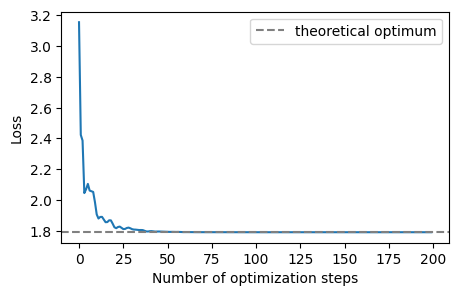

In [28]:
# define the optimizer and the number of optimization steps
opt = qml.AdamOptimizer(stepsize=0.1)
num_steps = 200
 
# optimize the circuit parameters to minimize the loss function
loss_history = []
for step in range(num_steps):
    weights, loss = opt.step_and_cost(loss_function, weights)
    loss_history.append(loss)
    if step % 20 == 0 or step == num_steps - 1:
        print(f"step {step:3d} | Loss = {loss:.4f}   "
              f"(optimum = {entropy:.4f})")
        

# plot the loss function with the number of optimization steps, and the theoretical optimum (entropy)
plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.axhline(entropy, ls="--", c="gray",
            label=r"theoretical optimum")
plt.xlabel("Number of optimization steps"); plt.ylabel("Loss")
plt.legend()
plt.show()

### Compare to the target distribution and visualize the generated samples

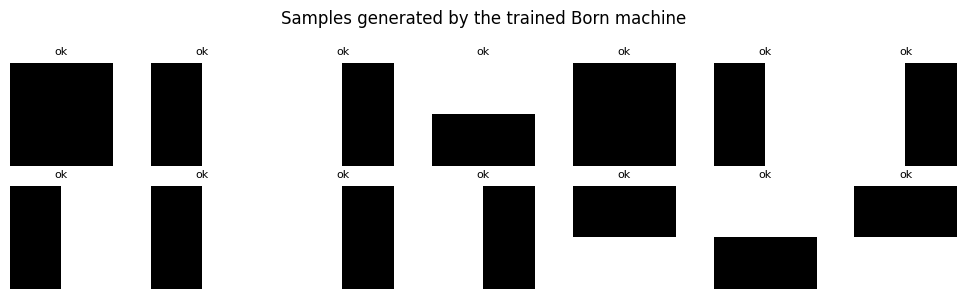

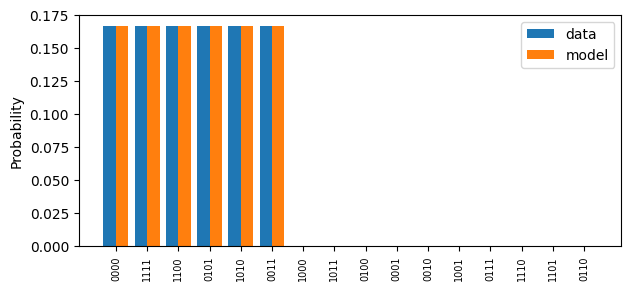

In [29]:
p_model = np.array(qcbm_probs(weights))
 
# visualize some samples from the trained model, and check if they are valid patterns
samples = np.random.choice(dim, size=14, p=p_model)
fig, axes = plt.subplots(2, 7, figsize=(10, 3))
for ax, k in zip(axes.flat, samples):
    ax.imshow(int_to_image(k), cmap="gray_r", vmin=0, vmax=1)
    ax.axis("off")
    ax.set_title("ok" if k in valid_ints else "invalid", fontsize=8)
fig.suptitle("Samples generated by the trained Born machine")
plt.tight_layout() 
plt.show()
 
# compare the underlying probability distributions of the data and the model
top = np.argsort(p_model)[::-1][:20]
x = np.arange(len(top))
plt.figure(figsize=(7, 3))
plt.bar(x - 0.2, p_data[top], width=0.4, label="data")
plt.bar(x + 0.2, p_model[top], width=0.4, label="model")
plt.xticks(x, [np.binary_repr(k, num_qubits) for k in top],
           rotation=90, fontsize=7)
plt.ylabel("Probability") 
plt.legend() 
plt.show()

### Generate samples from the trained model

        ┌────────────┐┌────────────┐     ┌────────────┐┌────────────┐»
   q_0: ┤ Ry(2.0256) ├┤ Rz(5.7473) ├──■──┤ Ry(4.3764) ├┤ Rz(3.4608) ├»
        ├────────────┤├────────────┤┌─┴─┐└────────────┘├────────────┤»
   q_1: ┤ Ry(3.7693) ├┤ Rz(4.7903) ├┤ X ├──────■───────┤ Ry(5.9021) ├»
        ├────────────┤├────────────┤└───┘    ┌─┴─┐     └────────────┘»
   q_2: ┤ Ry(1.0542) ├┤ Rz(2.0559) ├─────────┤ X ├───────────■───────»
        ├───────────┬┘├────────────┤         └───┘         ┌─┴─┐     »
   q_3: ┤ Ry(5.362) ├─┤ Rz(3.6885) ├───────────────────────┤ X ├─────»
        └───────────┘ └────────────┘                       └───┘     »
meas: 4/═════════════════════════════════════════════════════════════»
                                                                     »
«                                     ┌────────────┐┌────────────┐»
«   q_0: ─────────────────────■───────┤ Ry(2.1065) ├┤ Rz(5.0878) ├»
«        ┌────────────┐     ┌─┴─┐     └────────────┘├────────────┤»
«   q_1: ┤ Rz(2

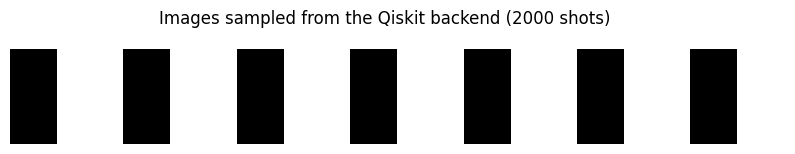

In [30]:
qc = QuantumCircuit(num_qubits)
w = np.array(weights) # the trained parameters
for layer in range(num_layers):            
    for q in range(num_qubits):
        qc.ry(w[layer, q, 0], q)
        qc.rz(w[layer, q, 1], q)
    for q in range(num_qubits - 1):
        qc.cx(q, q + 1)
qc.measure_all()
 
print(qc.draw()) # generator to sample that has been trained 

# define the number of shots
shots = 2000
result = StatevectorSampler().run([qc], shots=shots).result()
counts = result[0].data.meas.get_counts()
 
# Qiskit orders bitstrings little-endian (qubit 0 = rightmost bit),
# while our pixel convention put qubit 0 first. So we need to reverse it
shot_samples = [int(bitstring[::-1], 2) for bitstring in counts
                for _ in range(counts[bitstring])]
 
frac_valid = np.mean([k in valid_ints for k in shot_samples])
print(f"Fraction of valid Bars-and-Stripes patterns in {shots} shots: {frac_valid:.3f}")
 
fig, axes = plt.subplots(1, 7, figsize=(10, 1.8))
for ax, k in zip(axes, shot_samples[:7]):
    ax.imshow(int_to_image(k), cmap="gray_r", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle(f"Images sampled from the Qiskit backend ({shots} shots)")
plt.show()